In [1]:
import polars as pl

# filter metadata to HQ viruses
hq_votus = (
    pl.read_csv('votus_metadata_extended.tsv', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'checkv_quality', 'viral_confidence', 'uhgv_taxonomy', 'host_lineage_gtdb_r207', 'host_prediction_method', 'lifestyle', 'lifestyle_evidence'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns([
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vOTU-')).then(pl.col('uhgv_taxonomy').str.split(';vOTU-').list[-1]).otherwise(pl.lit(None)).alias('virus_species'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBGEN-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBGEN-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subgenus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vGENUS-')).then(pl.col('uhgv_taxonomy').str.split(';vGENUS-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_genus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBFAM-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subfamily'),
            pl.when(pl.col('uhgv_taxonomy').str.contains('vFAM-')).then(pl.col('uhgv_taxonomy').str.split('vFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_family'),
        ])
)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [2]:
hq_votus.group_by('lifestyle').len()

lifestyle,len
str,u32
"""lytic""",21495
"""temperate""",36019


In [10]:
hq_votus.filter(pl.col('checkv_quality') == 'Complete').group_by('lifestyle').len()

lifestyle,len
str,u32
"""temperate""",12666
"""lytic""",11491


In [12]:
hq_votus.filter(pl.col('checkv_quality') != 'Complete').group_by('lifestyle').len()

lifestyle,len
str,u32
"""temperate""",23353
"""lytic""",10004


In [4]:
(
        hq_votus
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

lifestyle_agreement,virus_level
f64,str
1.0,"""family"""
0.606061,"""family"""
0.97561,"""family"""
1.0,"""family"""
1.0,"""family"""
…,…
1.0,"""family"""
1.0,"""family"""
1.0,"""family"""


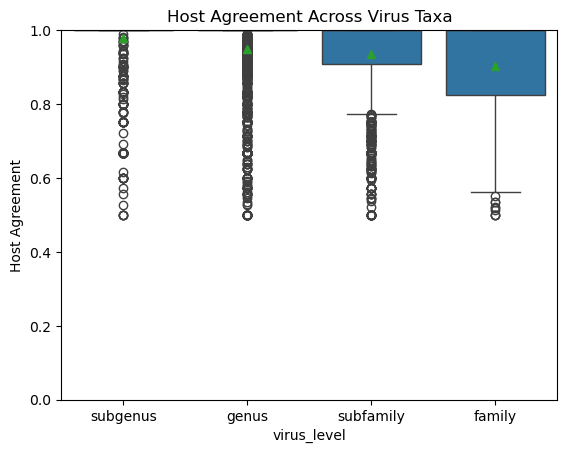

In [6]:
lifestyle_stats_lst = []

for virus_level in ['subgenus', 'genus', 'subfamily', 'family']:
    lifestyle_stats_lst.append(
        hq_votus
            .group_by(['lifestyle', f'virus_{virus_level}'])
            .agg([
                pl.len().alias('lifestyle_count')
            ])
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('lifestyle_count').sum().alias('virus_total'),
                pl.col('lifestyle_count').max().alias('virus_max_lifestyle_count')
            ])
            .filter(pl.col('virus_total') >= 3)
            .with_columns([
                (pl.col('virus_max_lifestyle_count') / pl.col('virus_total')).alias('lifestyle_agreement'),
                pl.lit(virus_level).alias('virus_level')
            ])
            [['lifestyle_agreement', 'virus_level']]
    )

plot_df = pl.concat(lifestyle_stats_lst)

# create boxplot of host phylum agreement
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=plot_df, y='lifestyle_agreement', x='virus_level', showmeans=True)
plt.ylim(0,1)
plt.ylabel('Host Agreement')
plt.title('Host Agreement Across Virus Taxa')
plt.show()

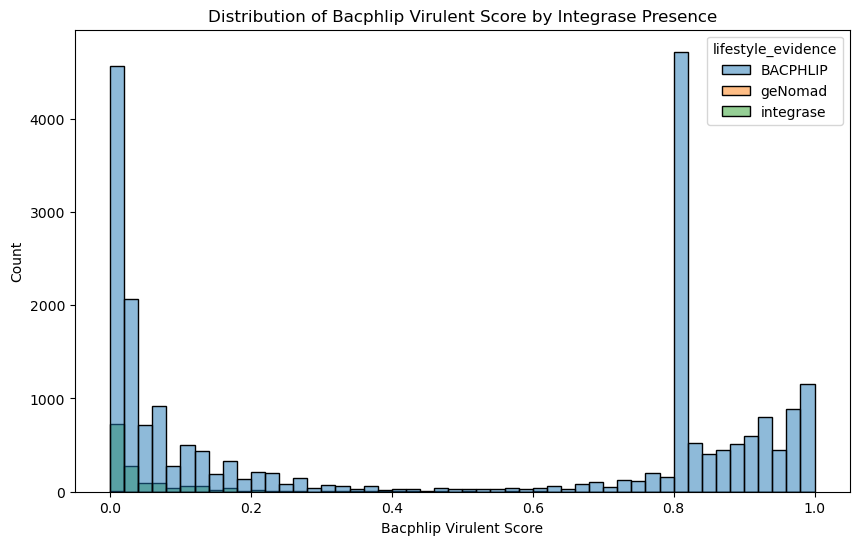

In [1]:
# load votus metadata
import polars as pl

votus_metadata = (
    pl.read_csv('votus_metadata_extended.tsv', separator='\t', columns=['bacphlip_virulent_score', 'checkv_quality', 'has_integrase', 'lifestyle_evidence'])
)

import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram of bacphlip_virulent_score colored by has_integrase
plt.figure(figsize=(10, 6))
sns.histplot(data=votus_metadata.filter(pl.col('checkv_quality') == 'Complete'), x='bacphlip_virulent_score', hue='lifestyle_evidence', bins=50)
plt.title('Distribution of Bacphlip Virulent Score by Integrase Presence')
plt.xlabel('Bacphlip Virulent Score')
plt.ylabel('Count')
# plt.yscale('log')
# plt.legend(title='Has Integrase')
plt.show()

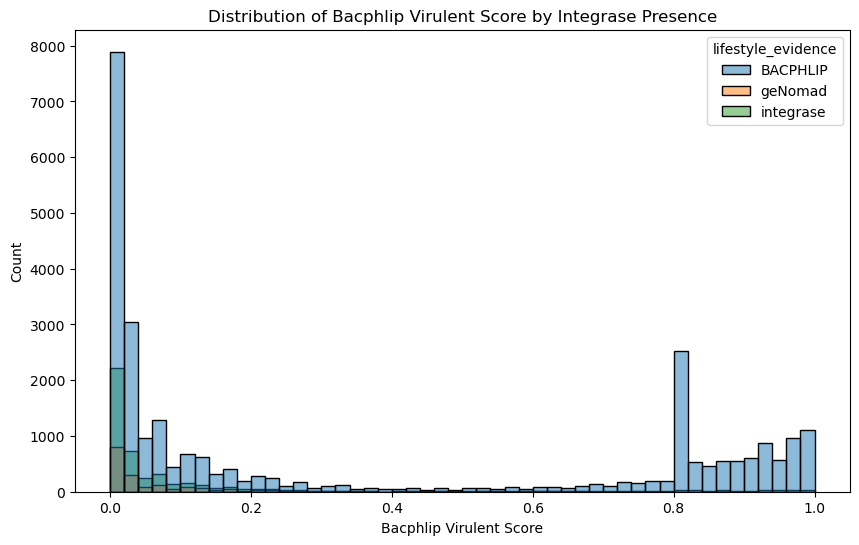

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram of bacphlip_virulent_score colored by has_integrase
plt.figure(figsize=(10, 6))
sns.histplot(data=votus_metadata.filter(pl.col('checkv_quality') == 'High-quality'), x='bacphlip_virulent_score', hue='lifestyle_evidence', bins=50)
plt.title('Distribution of Bacphlip Virulent Score by Integrase Presence')
plt.xlabel('Bacphlip Virulent Score')
plt.ylabel('Count')
# plt.yscale('log')
# plt.legend(title='Has Integrase')
plt.show()

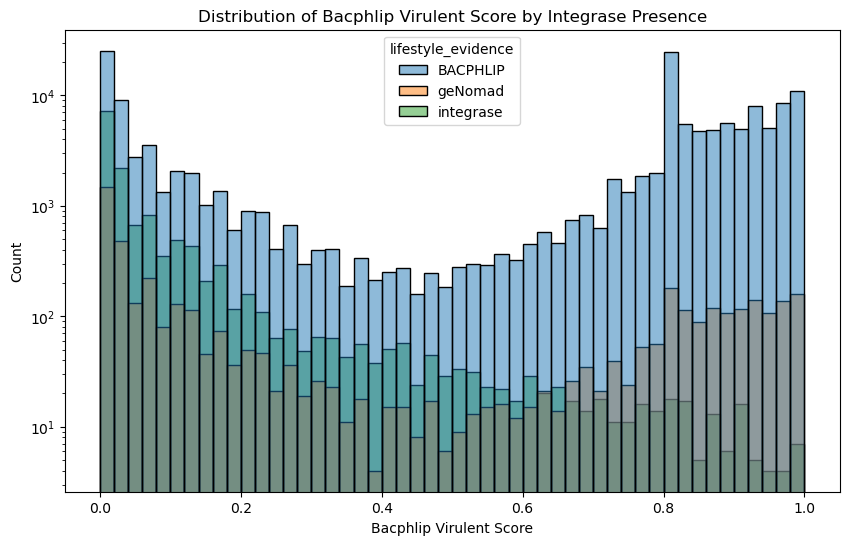

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram of bacphlip_virulent_score colored by has_integrase
plt.figure(figsize=(10, 6))
sns.histplot(data=votus_metadata, x='bacphlip_virulent_score', hue='lifestyle_evidence', bins=50)
plt.title('Distribution of Bacphlip Virulent Score by Integrase Presence')
plt.xlabel('Bacphlip Virulent Score')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

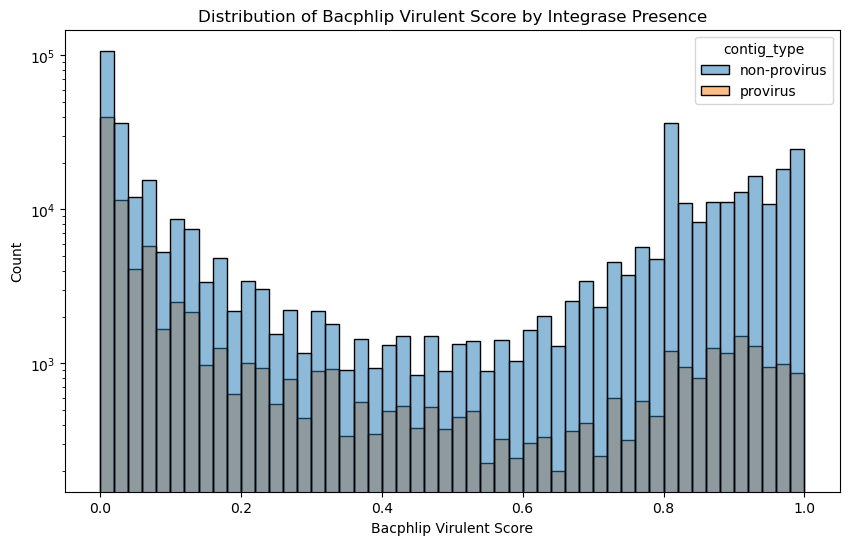

In [26]:
# load bacphlip results for UHVDB
import glob

bacphlip_lst = []
for file in glob.glob('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/uhvdb_*_chunks/*.fna.bacphlip'):
    df = (
        pl.read_csv(file, separator='\t', null_values=['NA'], new_columns=['contig_id', 'virulent', 'temperate'])
    )
    bacphlip_lst.append(df)

bacphlip_df = (
    pl.concat(bacphlip_lst)
        .with_columns([
            pl.when(pl.col('contig_id').str.contains('provirus')).then(pl.lit('provirus')).otherwise(pl.lit('non-provirus')).alias('contig_type')
        ])
)

import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram of bacphlip_virulent_score colored by has_integrase
plt.figure(figsize=(10, 6))
sns.histplot(data=bacphlip_df, x='virulent', hue='contig_type', bins=50)
plt.title('Distribution of Bacphlip Virulent Score by Integrase Presence')
plt.xlabel('Bacphlip Virulent Score')
plt.ylabel('Count')
plt.yscale('log')
# plt.legend(title='Has Integrase')
plt.show()